# Week 2 Assignment 2

**Name:** Meghana Balappa Uppar  
**USN:** [1GV22CS038]

# **1. Data Loading and Basic Checking**


In [ ]:
import pandas as pd

df = pd.read_csv("netflix_titles[1].csv")  # Use exact file name after upload
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
# Basic checking
print(df.head(10))          # First 10 rows
print(df.shape)             # Rows & Columns
print(df.columns)           # Column names
print(df.info())            # Data types
print(df.isnull().sum())    # Missing values

  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans   
4      s5  TV Show                      Kota Factory   
5      s6  TV Show                     Midnight Mass   
6      s7    Movie  My Little Pony: A New Generation   
7      s8    Movie                           Sankofa   
8      s9  TV Show     The Great British Baking Show   
9     s10    Movie                      The Starling   

                        director  \
0                Kirsten Johnson   
1                            NaN   
2                Julien Leclercq   
3                            NaN   
4                            NaN   
5                  Mike Flanagan   
6  Robert Cullen, José Luis Ucha   
7                   Haile Gerima   
8                Andy Devonshire   
9                 Theod

# **2. Data Cleaning**

Handle Missing Values

In [ ]:
# Fill missing director and cast with 'Unknown'
df["director"].fillna("Unknown", inplace=True)
df["cast"].fillna("Unknown", inplace=True)
df["country"].fillna("Unknown", inplace=True)

# Drop rows where rating is missing (important column)
df.dropna(subset=["rating"], inplace=True)

/tmp/ipython-input-2641437132.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["director"].fillna("Unknown", inplace=True)
/tmp/ipython-input-2641437132.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

Standardize Casing

In [ ]:
df["type"] = df["type"].str.title()
df["rating"] = df["rating"].str.upper()

Convert Date Column

In [ ]:
df["date_added"] = pd.to_datetime(df["date_added"], format='mixed')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **3. Univariate and Bivariate Analysis**

Most Common Rating Category

In [ ]:
most_common_rating = df["rating"].value_counts().idxmax()
print("Most Common Rating:", most_common_rating)

Most Common Rating: TV-MA


Top 5 Countries by Content Count

In [ ]:
top_countries = df["country"].value_counts().head(5)
print(top_countries)

country
United States     2818
India              972
Unknown            830
United Kingdom     419
Japan              244
Name: count, dtype: int64


Content Type Analysis (Movie vs TV Show)

In [ ]:
print(df["type"].value_counts())

type
Movie      6129
Tv Show    2674
Name: count, dtype: int64


Average Release Year by Type

In [ ]:
df.groupby("type")["release_year"].mean()

,release_year
type,
Movie,2013.120574
Tv Show,2016.607704


# **4. Trend and Relationship Exploration**

Titles Added Per Year

In [ ]:
df["year_added"] = df["date_added"].dt.year
titles_per_year = df.groupby("year_added").size()
print(titles_per_year)

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     428
2017.0    1186
2018.0    1648
2019.0    2016
2020.0    1879
2021.0    1498
dtype: int64


Release Year vs Rating

In [ ]:
df.groupby("rating")["release_year"].mean().sort_values()

,release_year
rating,
G,1997.804878
UR,1999.333333
PG,2008.428571
PG-13,2009.314286
84 MIN,2010.000000
R,2010.471840
NR,2010.912500
TV-PG,2013.529548
TV-14,2013.655556


# **5. Visualizations**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Count Plot – Movies vs TV Shows

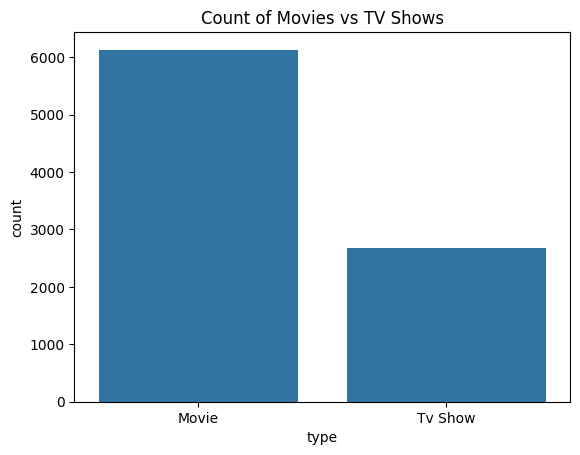

In [ ]:
plt.figure()
sns.countplot(x="type", data=df)
plt.title("Count of Movies vs TV Shows")
plt.show()

Bar Chart – Top 5 Countries

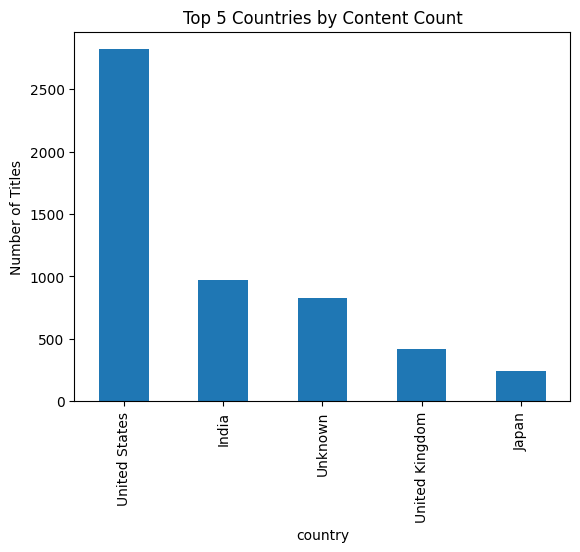

In [ ]:
plt.figure()
top_countries.plot(kind="bar")
plt.title("Top 5 Countries by Content Count")
plt.ylabel("Number of Titles")
plt.show()

Line Chart – Titles Added Per Year

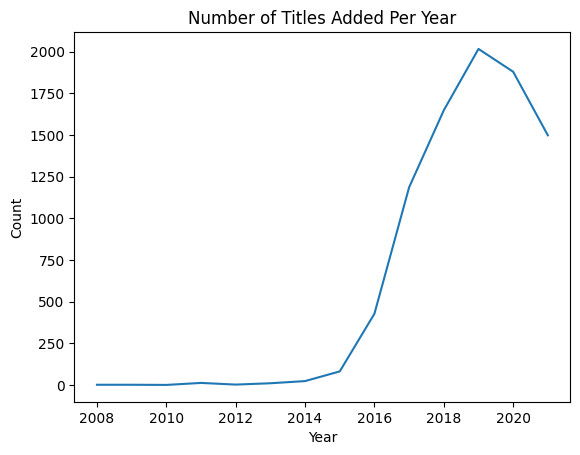

In [ ]:
plt.figure()
titles_per_year.plot()
plt.title("Number of Titles Added Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

Scatter Plot – Release Year vs Duration

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-366809560.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["duration_numeric"] = df["duration"].str.extract("(\d+)").astype(float)


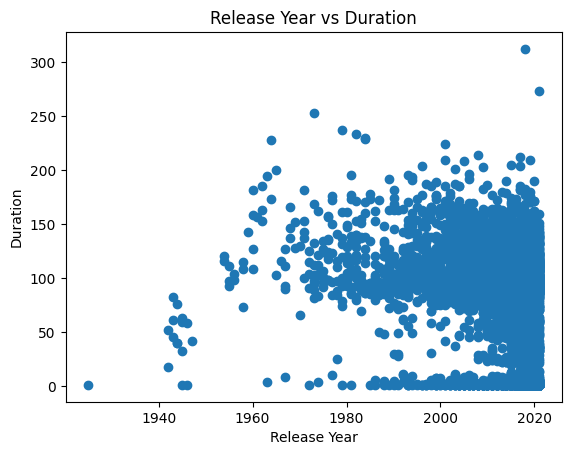

In [ ]:
# Extract numeric duration
df["duration_numeric"] = df["duration"].str.extract("(\d+)").astype(float)

plt.figure()
plt.scatter(df["release_year"], df["duration_numeric"])
plt.title("Release Year vs Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration")
plt.show()

Correlation Heatmap

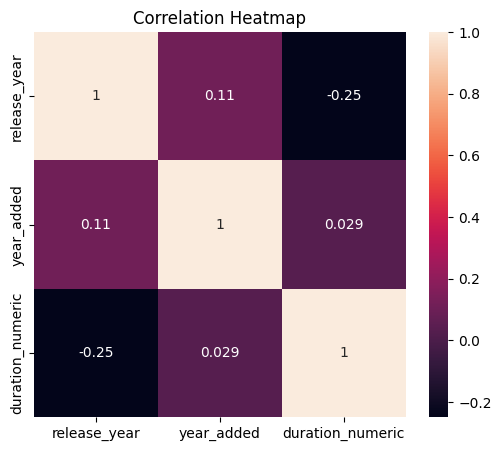

In [ ]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# **6. Conclusion and Insights**

1. Summarize key findings about Netflix content trends

### Key Findings

1. Movies dominate the Netflix platform compared to TV Shows.
2. The number of titles added to Netflix increased significantly after 2015.
3. The most common rating category indicates that Netflix primarily targets a mature audience.
4. Certain countries contribute more content, with the United States being one of the leading contributors.



2. Recommend one actionable insight for Netflix content strategy based on data patterns.

### Business Recommendation

Based on the increasing trend in content addition and dominance of certain rating categories, Netflix can focus on expanding content in high-demand genres and age groups. Additionally, investing in international content production in top-performing countries may increase global audience engagement.